
# ml_07_femi.ipynb

## Technical Modification: Retry-Enabled API Probe

This notebook applies a technical modification to the Module 7 deployed model investigation.

- Author: Oluwafemi Salawu
- Date: 2026-08-03
- API: ML Penguin Predictor
- Endpoint: https://ml-penguin-predictor.onrender.com/predict
- Target: species

This notebook:

- calls the live Penguin prediction API with requests
- uses retry/timeout handling for sleeping deployed servers
- creates structured DataFrames from API responses
- runs a bill_length_mm feature sweep to find the prediction shift
- tests edge cases and API error handling
- saves visuals to docs/images/
- logs the run to the root project.log

The project log showed timeout responses when the deployed server may have been sleeping, so this notebook adds retry logic and logs each API call result.


In [11]:
from __future__ import annotations

from importlib.metadata import PackageNotFoundError, version
import logging
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import pandas as pd

In [12]:
NOTEBOOK_NAME = "ml_07_femi.ipynb"

# Make the notebook work whether it is launched from the project root or notebooks/
CWD = Path.cwd()
ROOT_DIR = CWD.parent if CWD.name == "notebooks" else CWD
PROJECT_LOG = ROOT_DIR / "project.log"
IMAGE_DIR = ROOT_DIR / "docs" / "images"
DATA_DIR = ROOT_DIR / "data" / "processed"

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

LOG = logging.getLogger("M07")
LOG.setLevel(logging.DEBUG)
LOG.propagate = False

# Clear existing handlers so repeated notebook runs do not duplicate log lines.
for handler in list(LOG.handlers):
    LOG.removeHandler(handler)
    handler.close()

formatter = logging.Formatter(
    fmt="%(asctime)s | %(levelname)s | M07 | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)

file_handler = logging.FileHandler(PROJECT_LOG, mode="a", encoding="utf-8")
file_handler.setLevel(logging.DEBUG)
file_handler.setFormatter(formatter)
LOG.addHandler(file_handler)

stream_handler = logging.StreamHandler(sys.stdout)
stream_handler.setLevel(logging.INFO)
stream_handler.setFormatter(formatter)
LOG.addHandler(stream_handler)


def package_version(package_name: str) -> str:
    """Return installed package version or NOT INSTALLED."""
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "NOT INSTALLED"


LOG.info("========================")
LOG.info("=== RUN START ===")
LOG.info("project=M07")
LOG.info(f"repo_dir={ROOT_DIR.name}")
LOG.info(f"notebook={NOTEBOOK_NAME}")
LOG.info(f"python={platform.python_version()}")
LOG.info(f"os={platform.system()} {platform.release()}")
LOG.info("shell=notebook")
LOG.info(f"cwd={Path.cwd()}")
LOG.info(f"project_log={PROJECT_LOG}")
LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {package_version('pandas')}")
LOG.info(f"  numpy:        {package_version('numpy')}")
LOG.info(f"  matplotlib:   {package_version('matplotlib')}")
LOG.info(f"  seaborn:      {package_version('seaborn')}")
LOG.info(f"  requests:     {package_version('requests')}")
LOG.info("========================")

print(f"Project log path: {PROJECT_LOG}")

2026-08-03 17:59:35 | INFO | M07 | ========================
2026-08-03 17:59:35 | INFO | M07 | === RUN START ===
2026-08-03 17:59:35 | INFO | M07 | project=M07
2026-08-03 17:59:35 | INFO | M07 | repo_dir=ml-07-applied
2026-08-03 17:59:35 | INFO | M07 | notebook=ml_07_femi.ipynb
2026-08-03 17:59:35 | INFO | M07 | python=3.14.2
2026-08-03 17:59:35 | INFO | M07 | os=Windows 11
2026-08-03 17:59:35 | INFO | M07 | shell=notebook
2026-08-03 17:59:35 | INFO | M07 | cwd=c:\Repos\ml-07-applied\notebooks
2026-08-03 17:59:35 | INFO | M07 | project_log=c:\Repos\ml-07-applied\project.log
2026-08-03 17:59:35 | INFO | M07 | Confirming installation:
2026-08-03 17:59:35 | INFO | M07 |   python:       3.14.2
2026-08-03 17:59:35 | INFO | M07 |   pandas:       3.0.5
2026-08-03 17:59:35 | INFO | M07 |   numpy:        2.5.1
2026-08-03 17:59:35 | INFO | M07 |   matplotlib:   3.11.1
2026-08-03 17:59:35 | INFO | M07 |   seaborn:      0.13.2
2026-08-03 17:59:35 | INFO | M07 |   requests:     2.34.2
2026-08-03 17

## 1. Configure API endpoint and example payloads

In [13]:
import time
from typing import Any

import requests

API_ENDPOINT = "https://ml-penguin-predictor.onrender.com/predict"

BASELINE_PAYLOADS: list[dict[str, Any]] = [
    {
        "expected": "Adelie",
        "bill_length_mm": 39.1,
        "bill_depth_mm": 18.7,
        "flipper_length_mm": 181,
        "body_mass_g": 3750,
    },
    {
        "expected": "Chinstrap",
        "bill_length_mm": 48.7,
        "bill_depth_mm": 17.5,
        "flipper_length_mm": 191,
        "body_mass_g": 3500,
    },
    {
        "expected": "Gentoo",
        "bill_length_mm": 46.1,
        "bill_depth_mm": 13.2,
        "flipper_length_mm": 211,
        "body_mass_g": 4500,
    },
]

LOG.info(f"API endpoint: {API_ENDPOINT}")
LOG.info("Configured baseline payloads for Adelie, Chinstrap, and Gentoo")

2026-08-03 17:59:35 | INFO | M07 | API endpoint: https://ml-penguin-predictor.onrender.com/predict
2026-08-03 17:59:35 | INFO | M07 | Configured baseline payloads for Adelie, Chinstrap, and Gentoo


## 2. Define retry-enabled prediction function

In [14]:
def predict_with_retry(
    payload: dict[str, Any],
    *,
    max_attempts: int = 3,
    timeout_seconds: int = 30,
    sleep_seconds: int = 3,
) -> dict[str, Any]:
    """Call the deployed API with retry support and return a structured result."""
    expected = payload.get("expected", "unknown")
    request_payload = {k: v for k, v in payload.items() if k != "expected"}

    for attempt in range(1, max_attempts + 1):
        try:
            LOG.info(f"Calling API for expected={expected}, attempt={attempt}")
            response = requests.post(
                API_ENDPOINT,
                json=request_payload,
                timeout=timeout_seconds,
            )
            response.raise_for_status()
            response_json = response.json()
            prediction = response_json.get("prediction", response_json)
            LOG.info(f"API success expected={expected} prediction={prediction}")
            return {
                "expected": expected,
                "prediction": prediction,
                "status": "OK",
                "attempts": attempt,
                "error": "",
                **request_payload,
            }
        except requests.exceptions.Timeout as exc:
            LOG.warning(f"API timeout expected={expected} attempt={attempt}: {exc}")
            if attempt < max_attempts:
                time.sleep(sleep_seconds)
        except requests.exceptions.RequestException as exc:
            LOG.warning(
                f"API request error expected={expected} attempt={attempt}: {exc}"
            )
            return {
                "expected": expected,
                "prediction": "ERROR",
                "status": "ERROR",
                "attempts": attempt,
                "error": str(exc),
                **request_payload,
            }

    LOG.error(f"API failed after retries expected={expected}")
    return {
        "expected": expected,
        "prediction": "TIMEOUT",
        "status": "TIMEOUT",
        "attempts": max_attempts,
        "error": "server may be sleeping or unavailable",
        **request_payload,
    }

## 3. Run baseline predictions

In [15]:
LOG.info("Baseline predictions with retry handling:")

baseline_results = [predict_with_retry(payload) for payload in BASELINE_PAYLOADS]
baseline_df = pd.DataFrame(baseline_results)

for row in baseline_results:
    marker = "OK" if row["expected"] == row["prediction"] else "MISMATCH"
    LOG.info(
        f"  expected={row['expected']:<10s} got={str(row['prediction']):<10s} "
        f"status={row['status']} attempts={row['attempts']} [{marker}]"
    )

baseline_output = DATA_DIR / "ml_07_femi_baseline_predictions.csv"
baseline_df.to_csv(baseline_output, index=False)
LOG.info(f"Saved baseline predictions to: {baseline_output}")

baseline_df

2026-08-03 17:59:35 | INFO | M07 | Baseline predictions with retry handling:
2026-08-03 17:59:35 | INFO | M07 | Calling API for expected=Adelie, attempt=1
2026-08-03 18:00:05 | WARNING | M07 | API timeout expected=Adelie attempt=1: HTTPSConnectionPool(host='ml-penguin-predictor.onrender.com', port=443): Read timed out. (read timeout=30)
2026-08-03 18:00:08 | INFO | M07 | Calling API for expected=Adelie, attempt=2
2026-08-03 18:00:26 | INFO | M07 | API success expected=Adelie prediction=Adelie
2026-08-03 18:00:26 | INFO | M07 | Calling API for expected=Chinstrap, attempt=1
2026-08-03 18:00:26 | INFO | M07 | API success expected=Chinstrap prediction=Chinstrap
2026-08-03 18:00:26 | INFO | M07 | Calling API for expected=Gentoo, attempt=1
2026-08-03 18:00:27 | INFO | M07 | API success expected=Gentoo prediction=Gentoo
2026-08-03 18:00:27 | INFO | M07 |   expected=Adelie     got=Adelie     status=OK attempts=2 [OK]
2026-08-03 18:00:27 | INFO | M07 |   expected=Chinstrap  got=Chinstrap  statu

,expected,prediction,status,attempts,error,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Adelie,OK,2,,39.1,18.7,181,3750
1,Chinstrap,Chinstrap,OK,1,,48.7,17.5,191,3500
2,Gentoo,Gentoo,OK,1,,46.1,13.2,211,4500


## 4. Run bill_length_mm sweep

In [16]:
LOG.info("bill_length_mm sweep with retry handling:")

sweep_values = [30 + (60 - 30) * i / 19 for i in range(20)]
sweep_payloads = [
    {
        "expected": "unknown",
        "bill_length_mm": value,
        "bill_depth_mm": 18.0,
        "flipper_length_mm": 190,
        "body_mass_g": 3800,
    }
    for value in sweep_values
]

sweep_results = [
    predict_with_retry(payload, max_attempts=2) for payload in sweep_payloads
]
sweep_df = pd.DataFrame(sweep_results)

LOG.info(" bill_length_mm prediction")
for _, row in sweep_df.iterrows():
    LOG.info(f"      {row['bill_length_mm']:.6f}     {row['prediction']}")

sweep_output = DATA_DIR / "ml_07_femi_bill_length_sweep.csv"
sweep_df.to_csv(sweep_output, index=False)
LOG.info(f"Saved sweep results to: {sweep_output}")

sweep_df[["bill_length_mm", "prediction", "status", "attempts"]]

2026-08-03 18:00:27 | INFO | M07 | bill_length_mm sweep with retry handling:
2026-08-03 18:00:27 | INFO | M07 | Calling API for expected=unknown, attempt=1
2026-08-03 18:00:27 | INFO | M07 | API success expected=unknown prediction=Adelie
2026-08-03 18:00:27 | INFO | M07 | Calling API for expected=unknown, attempt=1
2026-08-03 18:00:27 | INFO | M07 | API success expected=unknown prediction=Adelie
2026-08-03 18:00:27 | INFO | M07 | Calling API for expected=unknown, attempt=1
2026-08-03 18:00:27 | INFO | M07 | API success expected=unknown prediction=Adelie
2026-08-03 18:00:27 | INFO | M07 | Calling API for expected=unknown, attempt=1
2026-08-03 18:00:28 | INFO | M07 | API success expected=unknown prediction=Adelie
2026-08-03 18:00:28 | INFO | M07 | Calling API for expected=unknown, attempt=1
2026-08-03 18:00:28 | INFO | M07 | API success expected=unknown prediction=Adelie
2026-08-03 18:00:28 | INFO | M07 | Calling API for expected=unknown, attempt=1
2026-08-03 18:00:28 | INFO | M07 | API 

,bill_length_mm,prediction,status,attempts
0,30.000000,Adelie,OK,1
1,31.578947,Adelie,OK,1
2,33.157895,Adelie,OK,1
3,34.736842,Adelie,OK,1
4,36.315789,Adelie,OK,1
5,37.894737,Adelie,OK,1
6,39.473684,Adelie,OK,1
7,41.052632,Adelie,OK,1
8,42.631579,Adelie,OK,1
9,44.210526,Chinstrap,OK,1


## 5. Visualize prediction shift

2026-08-03 18:00:31 | INFO | M07 | Saved figure: c:\Repos\ml-07-applied\docs\images\ml_07_femi_bill_length_sweep.png


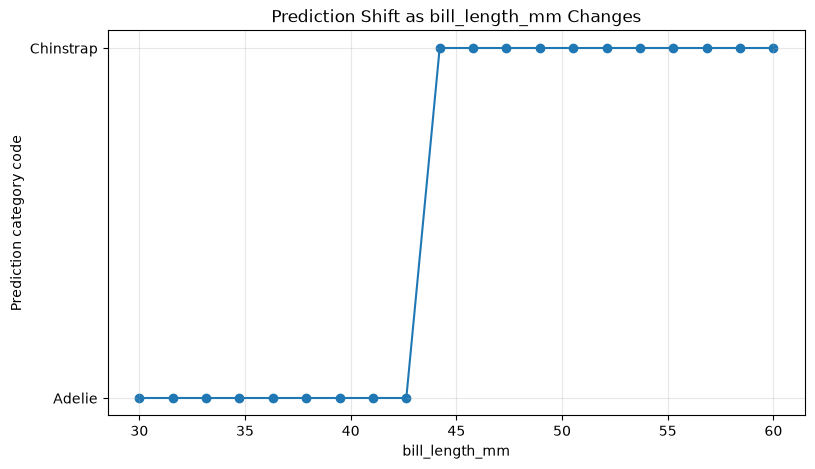

In [17]:
plot_df = sweep_df.copy()
plot_df["prediction_code"] = plot_df["prediction"].astype("category").cat.codes

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(plot_df["bill_length_mm"], plot_df["prediction_code"])
ax.plot(plot_df["bill_length_mm"], plot_df["prediction_code"])
ax.set_title("Prediction Shift as bill_length_mm Changes")
ax.set_xlabel("bill_length_mm")
ax.set_ylabel("Prediction category code")
ax.set_yticks(sorted(plot_df["prediction_code"].unique()))
labels = (
    plot_df[["prediction", "prediction_code"]]
    .drop_duplicates()
    .sort_values("prediction_code")["prediction"]
    .tolist()
)
ax.set_yticklabels(labels)
ax.grid(True, alpha=0.3)

figure_path = IMAGE_DIR / "ml_07_femi_bill_length_sweep.png"
fig.savefig(figure_path, bbox_inches="tight")
LOG.info(f"Saved figure: {figure_path}")

plt.show()

## 6. Edge case testing

In [18]:
LOG.info("Edge case results:")

EDGE_CASES: list[dict[str, Any]] = [
    {
        "case": "missing feature",
        "payload": {
            "bill_length_mm": 39.1,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
        },
    },
    {
        "case": "extreme bill length",
        "payload": {
            "bill_length_mm": 5,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    },
    {
        "case": "very large bill",
        "payload": {
            "bill_length_mm": 90,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    },
    {
        "case": "negative value",
        "payload": {
            "bill_length_mm": -10,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    },
    {
        "case": "zero body mass",
        "payload": {
            "bill_length_mm": 39.1,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 0,
        },
    },
]

edge_rows: list[dict[str, Any]] = []

for item in EDGE_CASES:
    case_name = item["case"]
    payload = item["payload"]
    try:
        response = requests.post(API_ENDPOINT, json=payload, timeout=30)
        response.raise_for_status()
        response_json = response.json()
        prediction = response_json.get("prediction", response_json)
        status = "OK"
        error = ""
    except requests.exceptions.RequestException as exc:
        prediction = "ERROR"
        status = "ERROR"
        error = str(exc)

    LOG.info(f"  {case_name:<22s} -> {prediction if status == 'OK' else error}")
    edge_rows.append(
        {
            "case": case_name,
            "prediction": prediction,
            "status": status,
            "error": error,
            **payload,
        }
    )

edge_df = pd.DataFrame(edge_rows)
edge_output = DATA_DIR / "ml_07_femi_edge_cases.csv"
edge_df.to_csv(edge_output, index=False)
LOG.info(f"Saved edge case results to: {edge_output}")

edge_df

2026-08-03 18:00:31 | INFO | M07 | Edge case results:
2026-08-03 18:00:32 | INFO | M07 |   missing feature        -> 400 Client Error: Bad Request for url: https://ml-penguin-predictor.onrender.com/predict
2026-08-03 18:00:32 | INFO | M07 |   extreme bill length    -> Adelie
2026-08-03 18:00:32 | INFO | M07 |   very large bill        -> Chinstrap
2026-08-03 18:00:32 | INFO | M07 |   negative value         -> Adelie
2026-08-03 18:00:32 | INFO | M07 |   zero body mass         -> Adelie
2026-08-03 18:00:32 | INFO | M07 | Saved edge case results to: c:\Repos\ml-07-applied\data\processed\ml_07_femi_edge_cases.csv


,case,prediction,status,error,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,missing feature,ERROR,ERROR,400 Client Error: Bad Request for url: https:/...,39.1,18.7,181,NaN
1,extreme bill length,Adelie,OK,,5.0,18.7,181,3750.0
2,very large bill,Chinstrap,OK,,90.0,18.7,181,3750.0
3,negative value,Adelie,OK,,-10.0,18.7,181,3750.0
4,zero body mass,Adelie,OK,,39.1,18.7,181,0.0


## 7. Summary

In [19]:
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(
    "Technical modification: Added retry-enabled API calls and structured logging."
)
LOG.info(f"Baseline rows: {len(baseline_df)}")
LOG.info(f"Sweep rows: {len(sweep_df)}")
LOG.info(f"Edge case rows: {len(edge_df)}")
LOG.info(f"Outputs saved in: {DATA_DIR}")
LOG.info(f"Figures saved in: {IMAGE_DIR}")
LOG.info("Executed notebook successfully: ml_07_femi.ipynb")
LOG.info("========================")

2026-08-03 18:00:32 | INFO | M07 | ========================
2026-08-03 18:00:32 | INFO | M07 | SUMMARY
2026-08-03 18:00:32 | INFO | M07 | ========================
2026-08-03 18:00:32 | INFO | M07 | Technical modification: Added retry-enabled API calls and structured logging.
2026-08-03 18:00:32 | INFO | M07 | Baseline rows: 3
2026-08-03 18:00:32 | INFO | M07 | Sweep rows: 20
2026-08-03 18:00:32 | INFO | M07 | Edge case rows: 5
2026-08-03 18:00:32 | INFO | M07 | Outputs saved in: c:\Repos\ml-07-applied\data\processed
2026-08-03 18:00:32 | INFO | M07 | Figures saved in: c:\Repos\ml-07-applied\docs\images
2026-08-03 18:00:32 | INFO | M07 | Executed notebook successfully: ml_07_femi.ipynb
2026-08-03 18:00:32 | INFO | M07 | ========================
